Here is a **complete recap of your previously completed tasks** from the Superstore analysis program. [perplexity](https://www.perplexity.ai/search/71cdataframee88-535b-4896-a25e-5b48ff28888d)

## Day 1: Category/Sub-Category Sales (Completed ✅)
**Task**: Total sales by Category and Sub-Category, sorted descending.
**Your Code**:
```python
result = dataframe.groupby(['category','sub_category'])['sales'].sum().round(2).reset_index()
print(result.sort_values(by=['sales'], ascending=[False]))
```
**Your Output** (top lines):
```
           category sub_category      sales
16       Technology       Phones  330007.05
1         Furniture       Chairs  328449.10
11  Office Supplies      Storage  223843.61
...
```
**Your Insight**: Phones dominated (Technology category), chairs runner-up. Phones high due to frequent replacements vs furniture one-time buys. [perplexity](https://www.perplexity.ai/search/71cdataframee88-535b-4896-a25e-5b48ff28888d)

## Day 2: Monthly Growth by Category (Completed ✅)
**Task**: Latest month MoM % growth.
**Your Output**:
```
Office Supplies    -3.3
Furniture         -15.2
Technology        -56.0
```
**Your Insight**: Office Supplies least decline (96.7% retained) due to recurring demand (schools, offices); Technology sharp drop from post-season unsold stock. [perplexity](https://www.perplexity.ai/search/71cdataframee88-535b-4896-a25e-5b48ff28888d)

## Progress Summary
```
Days Complete: 1, 2 ✅
Current: Day 3 (Customer Analysis) — ready to run
Streak: Resumes at 1 today
Total Plan: 28 days / 4 weeks left
```

**Next**: Run Day 3 customer code (download CSV if needed), share table + 2-sentence insight. Calendar at 9 PM IST active. Ready? 🚀 [interviewquery](https://www.interviewquery.com/p/free-datasets)

In [ ]:
import pandas as pd
import requests

url = "https://gist.githubusercontent.com/nnbphuong/38db511db14542f3ba9ef16e69d3814c/raw/Superstore.csv"

# Download and save as CSV
response = requests.get(url)
with open("superstore.csv", "wb") as f:
    f.write(response.content)

print("Downloaded! Check superstore.csv")

# Verify columns
dataframe = pd.read_csv("superstore.csv")
# dataframe.head(3).T

Downloaded! Check superstore.csv


Understood! From now on, Rani will give **no code upfront** — only the **business question** and what to compute. You explore, investigate, and code yourself, asking for hints/code only when needed.

### ***Day 3*** 

**Business Question**: Who are the company's top 10 customers by total revenue, and what patterns do you see in their order frequency vs average order value?

**What to compute** (using superstore.csv):  
1. Group customers by name.  
2. Calculate: total_sales, order_count (unique orders), avg_order_value (total/order_count).  
3. Sort descending by total_sales, show top 10 with all 3 metrics.  

**Reply with**:  
1. Your table output.  
2. 2 sentences: High-freq/medium-spend or low-freq/high-value? Loyalty ideas?  
3. Time tracking.  

Explore and code it your way! 🚀

In [1]:
import pandas as pd

dataframe = pd.read_csv("superstore.csv")

# print("Shape:", dataframe.shape)

# display(dataframe.columns.tolist())

# display(dataframe.head(2).T)


def sanitize_columns(df):

    df.columns = df.columns.str.replace(" ", "_").str.replace("-","_").str.lower()

    return df


cleaned_df = sanitize_columns(dataframe)

df = cleaned_df.copy()

df["order_date"] = pd.to_datetime(df["order_date"])

customer_info = (
    df.groupby("customer_name")
    .agg(total_sales=("sales", "sum"), order_count=("order_id", "nunique"))
    .reset_index(drop=True)
)

customer_info["mean_order_value"] = (
    customer_info["total_sales"] / customer_info["order_count"]
)

top10 = customer_info.sort_values("total_sales", ascending=False).head(10)

bottom10:pd.DataFrame = customer_info.sort_values("total_sales", ascending=True).head(10)

In [2]:
low_value_threshold = customer_info["total_sales"].quantile(0.25)
high_freq_threshold = customer_info["order_count"].quantile(0.75)

low_value_high_freq = customer_info[
    (customer_info["total_sales"] <= low_value_threshold)
    & (customer_info["order_count"] >= high_freq_threshold)
]

low_value_high_freq

# display(bottom10.round(2))
# display(top10.round(2))

,total_sales,order_count,mean_order_value
10,1113.838,8,139.229750
16,914.532,9,101.614667
24,1056.390,9,117.376667
198,1050.636,9,116.737333
261,684.171,8,85.521375
364,1082.918,11,98.447091
524,776.384,9,86.264889
550,775.414,9,86.157111
652,1137.616,8,142.202000
654,945.222,8,118.152750


###  ***Insight***

- ***Customers having higher sales often have lower order counts not more than 5 against their total amount purchased, but seldom have order count greater than equal to 10 which shows these customers are high value low frequency customers.***
- ***There are also customers who have made lesser purchases and lesser frequency these customers are low value and low frequency customers.***

- ***There are also customers who have low value but also have high frequency in purchases.***

In [3]:
# frequency = (
#     df.groupby('customer_id').agg(total_sales=("sales", "sum"),order_count=("order_id", "nunique"))
#     .reset_index(drop=True)
# )

# frequency['mean_order'] = (frequency['total_sales'] / frequency['order_count']).round(2)

# Large/Real-time/Free-flowing data (e.g., 1M+ customers):
# ✅ Customer ID first (unique, fast joins, no name typos/dups)
# ❌ Name secondary (lookup via merge for reports)

# Small/Static datasets (<10K rows, analysis):
# ✅ Customer Name OK (readable, no perf issues)
# ✅ ID still better technically


In [4]:
df.columns.to_list()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

In [5]:
profit_margin = (df.groupby(['category','sub_category']).agg(
                                total_profit=('profit','sum'),
                                total_sales=('sales','sum')
                                ).reset_index())

profit_margin['margin_pct'] = (profit_margin['total_profit'] / profit_margin['total_sales']) * 100

pf10 = profit_margin.sort_values(by=['margin_pct'],ascending=False).head(10)


In [6]:
pf10

,category,sub_category,total_profit,total_sales,margin_pct
9,Office Supplies,Labels,5546.2540,12486.312,44.418672
10,Office Supplies,Paper,34053.5693,78479.206,43.391837
7,Office Supplies,Envelopes,6964.1767,16476.402,42.267582
14,Technology,Copiers,55617.8249,149528.030,37.195585
8,Office Supplies,Fasteners,949.5182,3024.280,31.396504
13,Technology,Accessories,41936.6357,167380.318,25.054700
5,Office Supplies,Art,6527.7870,27118.792,24.071083
4,Office Supplies,Appliances,18138.0054,107532.161,16.867517
6,Office Supplies,Binders,30221.7633,203412.733,14.857361
2,Furniture,Furnishings,13059.1436,91705.164,14.240358


### ***Insight***

- ***In the Office supplies category the sub categories → labels,paper,envelopes reign as top 3 with highest margin pct ranging from 44.4,43.2,42.26 respectively.***
- ***Out of Top 10 office supplies holds 7 places distributed apart from technology and furniture, so for a strategy give other two categories in discount and festive sale and clear the old stock and restock these categoroies only when they less than 30 or 25 percent of the original capacity and as for the majority increase their restock capacity to 50 or 60 percent as they are fast moving in sales and yield more profit than any other category.***

In [7]:
bottom10 : pd.DataFrame = profit_margin.sort_values('margin_pct').head(10)

display(bottom10.round(2))

,category,sub_category,total_profit,total_sales,margin_pct
3,Furniture,Tables,-17725.48,206965.53,-8.56
0,Furniture,Bookcases,-3472.56,114880.00,-3.02
12,Office Supplies,Supplies,-1189.10,46673.54,-2.55
15,Technology,Machines,3384.76,189238.63,1.79
1,Furniture,Chairs,26590.17,328449.10,8.10
11,Office Supplies,Storage,21278.83,223843.61,9.51
16,Technology,Phones,44515.73,330007.05,13.49
2,Furniture,Furnishings,13059.14,91705.16,14.24
6,Office Supplies,Binders,30221.76,203412.73,14.86
4,Office Supplies,Appliances,18138.01,107532.16,16.87


In [8]:
df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head()

sub_category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: sales, dtype: float64

In [9]:
df['sub_category'].value_counts()

sub_category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

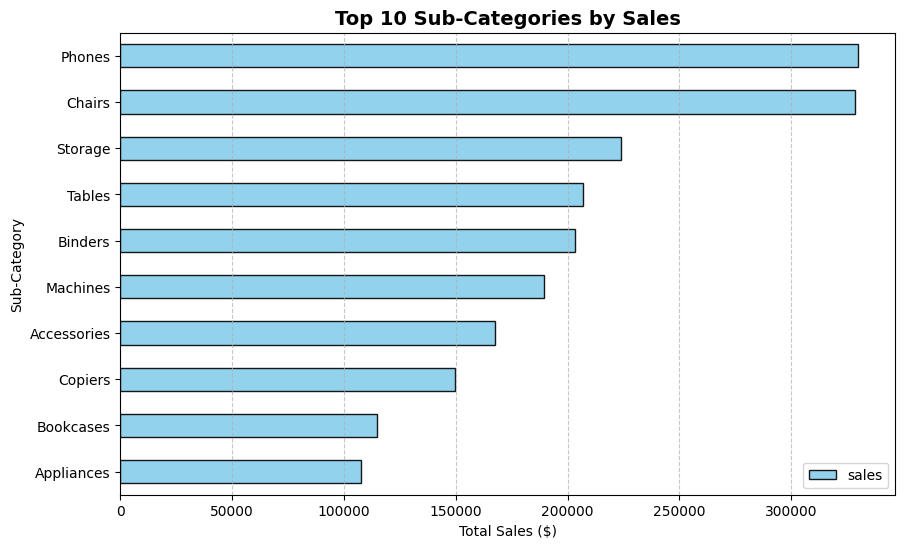

In [ ]:
ax =  (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .plot(
        kind="barh",
        figsize=(10, 6),
        # title="Top 5 Sub-Categories by Sales",
        color="skyblue",
        alpha=0.9,
        # facecolor="blue",
        # grid=True,
        edgecolor="black",
    )
)

# use this to learn how to customize the plot more
ax.invert_yaxis()
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Sub-Category")
ax.set_title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.7)
ax.legend().set_visible(True)

###  ***Insight***

- ***The top 5 sub-categories by sales are Phones, Chairs, Storage, Binders. Phones and Chairs are the top two sub-categories with the highest sales.***
- ***Phones have the highest sales, which could be due to the increasing demand for technology products and the frequent need for replacements. Chairs also have high sales, likely because they are essential office furniture items that are often purchased in bulk for office setups. Storage, Binders,contribute significantly to sales, indicating a strong demand for organizational and office equipment.***
- ***Outliers in sales data may exist for certain sub-categories, which could be due to one-time large purchases or unusual market conditions.***
- ***Anomalys in sales data may indicate seasonal trends, promotional events, or shifts in consumer preferences. For example, a spike in phone sales could be attributed to a new product launch or a holiday season promotion.***


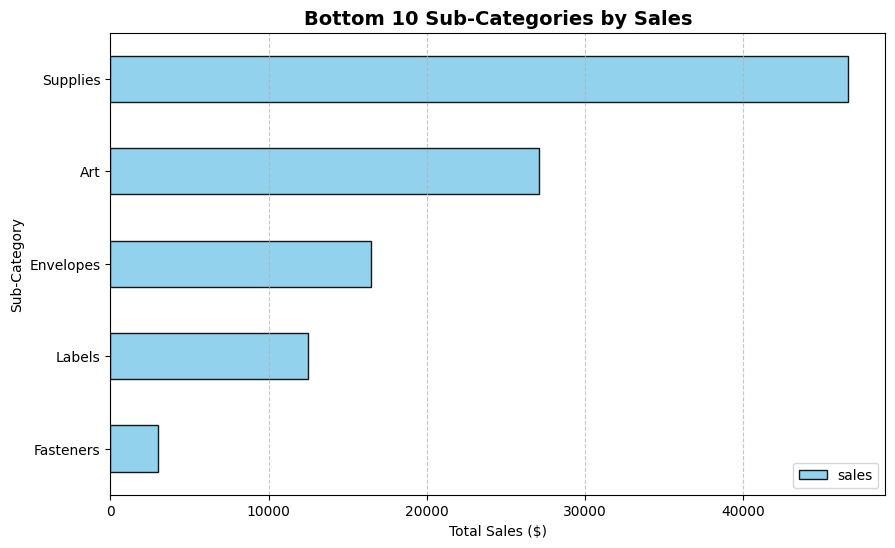

In [11]:
ax = (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
    .tail(5)
    .plot(
        kind="barh",
        figsize=(10, 6),
        # title="Bottom 5 Sub-Categories by Sales",
        color="skyblue",
        alpha=0.9,
        # facecolor="blue",
        # grid=True,
        edgecolor="black",
    )
)

# use this to learn how to customize the plot more
ax.invert_yaxis()
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Sub-Category")
ax.set_title("Bottom 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.7)
ax.legend().set_visible(True)

### ***Insight***

### ***Bottom 5 Sub-Categories by Total Sales***

- ***The Bottom Sub category are Supplies,Art,Envelopes,Labels,Fasteners***
- ***The Fasteners are least sold product with lowest in sales and margin percentage because they are not used or required by the customer daily they are required seldomly compared to the other four categories***